# 05 · Knowledge base, retrieval, and refusing to answer

A classifier that names a dish is half a product. The other half is saying something true
about it — and, more importantly, declining to say anything when the knowledge base does not
support it.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = ROOT / "artifacts" / "reports"

# Chart palette, validated for the lightness band, chroma floor, colour-vision
# separation and contrast. The interface accents fail as data marks: they sit
# too light and drop under 3:1 against the page. Order matters — green beside
# amber fails deuteranope separation, so teal sits between them.
INK, DIM = "#0b0b0f", "#4b4b55"
C = ["#e62429", "#1b4ce0", "#c07708", "#0e8fa3", "#16a34a"]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": DIM, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": DIM, "ytick.color": DIM,
    "axes.grid": True, "grid.color": "#e6e4dc", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False,
})

## Building the knowledge base

USDA SR Legacy has a record for 41 of the 101 dishes. The other 60 had to be composed from
weighted ingredient records — and that workaround turned out to be the most structurally
useful thing in the project, because each weight is a typed, quantified edge with a source
id attached.

Naive string matching against SR Legacy was unusable. Probed against all 101 class names it
produced *confidently wrong* answers: `beef_carpaccio` → "Soup, stock, beef" at 13 kcal,
`french_fries` → "French toast", `chocolate_cake` → "snack cakes, **not** chocolate". About
28 classes matched nothing and fell through to the same junk winner. That is why the mapping
is curated and auditable rather than automatic.

In [2]:
kb = json.loads((ROOT / "data" / "nutrition" / "kb.json").read_text())
entries = kb["entries"]
composite = [e for e in entries if e["method"] == "composite"]

print(f"classes            {kb['num_classes']}")
print(f"nutrients each     {len(kb['nutrients'])}")
print(f"measured directly  {len(entries) - len(composite)}")
print(f"composed           {len(composite)}")
print(f"review flags       {sum(len(e['review_flags']) for e in entries)}")
print(f"\nbasis: {kb['basis']}")

classes            101
nutrients each     32
measured directly  41
composed           60
review flags       0

basis: per 100 g edible portion; per-serving figures scaled by serving_g


## Retrieval quality

In [3]:
rag = json.loads((REPORTS / "rag_evaluation.json").read_text())
ret = pd.DataFrame(rag["retrieval"]).T
ret.index.name = "category"
ret.reset_index()

,category,n,recall@1,recall@5,answerable@1,mrr,ndcg
0,nutrient_lookup,48.0,64.58,100.0,100.0,0.8229,0.8693
1,ingredients,10.0,100.00,100.0,100.0,1.0000,1.0000
2,graph_inversion,8.0,75.00,87.5,75.0,0.8125,0.8289
3,superlative,4.0,100.00,100.0,100.0,1.0000,1.0000


**Strict recall@1 of 64.6% on nutrient lookups is a labelling artefact, not a failure.** Every
single miss returned a *portion* document where a *macros* document was labelled — and all 17
contained the correct figure, because both state per-serving macros. Penalising that measures
which document an annotator happened to name, not whether the pipeline can answer.

Both metrics are kept: strict recall stays comparable with published IR numbers, and
`answerable@1` measures whether the top hit can actually support the answer.

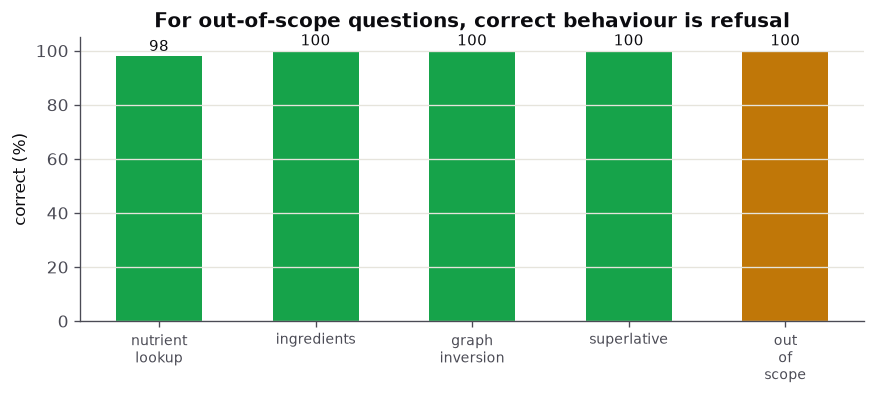

answered correctly  98.57%
refusal accuracy    100.0%   false refusals: 0
grounded            100.0%
cost of the run     $0.0244 over 99s


In [4]:
ans = rag["answers"]
cats = list(ans["by_category"].keys())
fig, ax = plt.subplots(figsize=(7.4, 3.4))
x = np.arange(len(cats))
correct = [ans["by_category"][c]["correct"] for c in cats]
cols = [C[4] if c != "out_of_scope" else C[2] for c in cats]
ax.bar(x, correct, color=cols, width=0.55)
ax.set_xticks(x); ax.set_xticklabels([c.replace("_", "\n") for c in cats], fontsize=8.5)
ax.set_ylabel("correct (%)"); ax.set_ylim(0, 105)
ax.set_title("For out-of-scope questions, correct behaviour is refusal")
ax.grid(axis="x", visible=False)
for i, v in enumerate(correct):
    ax.text(i, v + 2, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

o = ans["overall"]
print(f"answered correctly  {o['answered_correct']}%")
print(f"refusal accuracy    {o['refusal_accuracy']}%   false refusals: {o['false_refusals']}")
print(f"grounded            {o['grounded_rate']}%")
print(f"cost of the run     ${o['total_cost_usd']:.4f} over {o['wall_seconds']:.0f}s")

## The grounding gate

Every quantity in a generated answer is checked against the retrieved context, matched **per
unit** so milligrams can never be supported by the same digits in grams. An answer that fails
is withheld and a deterministic summary served in its place — not annotated and shown anyway.

It caught a real hallucination on the first live query. Asked for per-serving sodium, the
model answered 983.4 mg. That figure is *arithmetically correct* — 447 mg × 2.20 — and the
source even states the multiplier, but it appeared in no document, so it was rejected.

The right fix was the corpus, not the tolerance. The micronutrient documents stated only
per-100 g while the knowledge base had stored per-serving values all along, so the model had
to multiply to answer at all. Both bases are now written explicitly.

**When grounding fails on a derived number, remove the need to derive it.** Loosening the
check would have hidden exactly the class of error it exists to catch.

In [5]:
from nutrivision.rag.ground import check

context = "Minerals in Pizza, per 100 g and per serving of 2 slices (220 g): sodium 447 mg per 100 g (983.4 mg per serving)."
for answer in [
    "Pizza has 983.4 mg of sodium per serving [1].",   # in the sources
    "Pizza has about 1200 mg of sodium per serving.",  # invented
    "Pizza has 447 g of sodium per 100 g.",            # right digits, wrong unit
]:
    r = check(answer, context)
    print(f"{'PASS' if r.grounded else 'FAIL'}  {answer}")
    for c in r.unsupported:
        print(f"        unsupported: {c.text}  (nearest in sources: {c.nearest})")

PASS  Pizza has 983.4 mg of sodium per serving [1].
FAIL  Pizza has about 1200 mg of sodium per serving.
        unsupported: 1200 mg  (nearest in sources: 983.4)
FAIL  Pizza has 447 g of sodium per 100 g.
        unsupported: 447 g  (nearest in sources: 220.0)
